# 01 Data quality and cleaning

How the raw workbook became the cleaned transactions table, and what was quarantined or flagged on the way.

> Data: Online Retail II, UCI Machine Learning Repository (Chen, 2019, CC BY 4.0). Historical transactions from 1 Dec 2009 to 9 Dec 2011. This notebook reads the PostgreSQL tables produced by `gci import-data`, `gci build-analytics`, `gci build-features` and `gci train`; reusable logic lives in the `gci` package, not here.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import Markdown, display
from sqlalchemy import text
from gci.db.session import session_scope
from gci.api.sqlfiles import load_sql
sns.set_theme(style="whitegrid", palette=["#1D4ED8", "#94A3B8", "#0F1F3D", "#B45309"])
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
GBP = lambda v: f"£{v:,.0f}"

def q(sql, **params):
    with session_scope() as s:
        return pd.read_sql(text(sql) if isinstance(sql, str) else sql, s.connection(), params=params)

def findings(items):
    display(Markdown("\n".join(f"{i+1}. {t}" for i, t in enumerate(items))))

## 1. Import runs and row counts

Every import records the file checksum, sheet coverage, and how many rows were accepted, quarantined or flagged.

In [2]:
from gci.ingest.quality import quality_report
with session_scope() as s:
    report = quality_report(s)
imports = pd.DataFrame(report["imports"])[["id","source_kind","status","rows_read","rows_accepted","rows_excluded","rows_flagged","file_sha256","started_at"]]
display(imports)
print("Sheets:", report["imports"][0]["sheets"])
print(f"Rows read {report['rows_read']:,} | accepted {report['rows_accepted']:,} | excluded {report['rows_excluded']:,} | accepted-but-flagged {report['rows_flagged']:,}")

,id,source_kind,status,rows_read,rows_accepted,rows_excluded,rows_flagged,file_sha256,started_at
0,1,xlsx,succeeded,1067371,1038819,28552,262223,bcbe73b35f5b7babf197fb0cb983a11f5d9ff929078d4a...,2026-09-21 19:57:06.820146+00:00


Sheets: [{'name': 'Year 2009-2010', 'rows': 525461, 'accepted': 521771, 'last_date': '2010-12-09T20:01:00', 'first_date': '2009-12-01T07:45:00'}, {'name': 'Year 2010-2011', 'rows': 541910, 'accepted': 517048, 'last_date': '2011-12-09T12:50:00', 'first_date': '2010-12-01T08:26:00'}]
Rows read 1,067,371 | accepted 1,038,819 | excluded 28,552 | accepted-but-flagged 262,223


## 2. Why rows were quarantined, and which kept rows carry flags

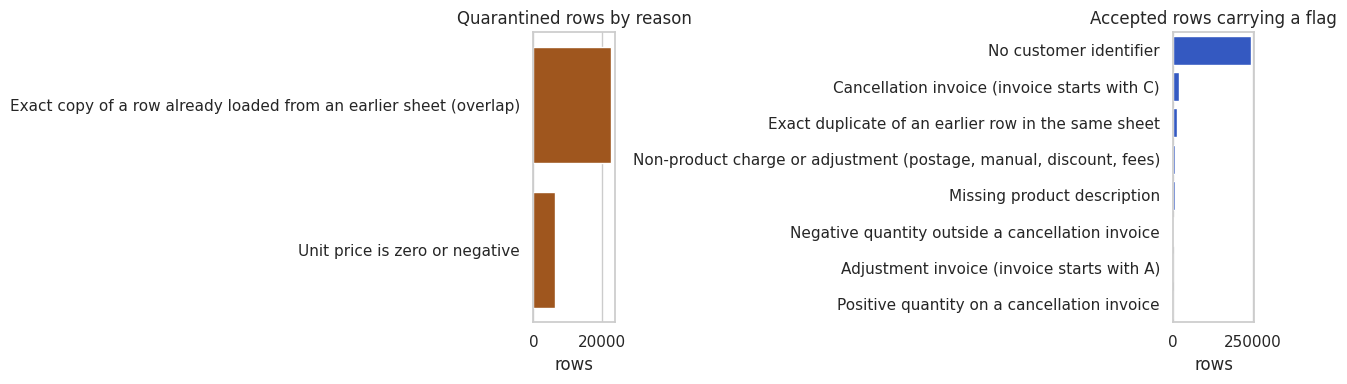

,reason,rows,share
0,duplicate_cross_sheet,22523,0.02
1,non_positive_price,6207,0.01


,reason,rows,share
0,anonymous,243007,0.23
1,cancellation,19494,0.02
2,duplicate_within_sheet,11812,0.01
3,non_product,5913,0.01
4,missing_description,4382,0.00
5,negative_quantity_not_cancellation,3457,0.00
6,adjustment_invoice,6,0.00
7,positive_quantity_on_cancellation,1,0.00


In [3]:
excl = pd.DataFrame(report["exclusion_reasons"]); flags = pd.DataFrame(report["flags"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=excl, y="label", x="rows", ax=axes[0], color="#B45309"); axes[0].set_title("Quarantined rows by reason"); axes[0].set_xlabel("rows"); axes[0].set_ylabel("")
sns.barplot(data=flags, y="label", x="rows", ax=axes[1], color="#1D4ED8"); axes[1].set_title("Accepted rows carrying a flag"); axes[1].set_xlabel("rows"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()
display(excl[["reason","rows","share"]]); display(flags[["reason","rows","share"]])

## 3. Duplicate investigation

Exact duplicates (all eight fields identical) were investigated before any removal. The two worksheets overlap on 1-9 December 2010, which explains most of them.

In [4]:
dup = report["duplicates"]; print(dup["decision"]); print()
overlap = q("""
SELECT sheet_name, min(invoice_date_raw) AS first_date, max(invoice_date_raw) AS last_date, count(*) AS rows
FROM raw_transactions GROUP BY sheet_name ORDER BY 1""")
display(overlap)
within = q("""
SELECT invoice_raw AS invoice, stock_code_raw AS stock_code, quantity_raw AS qty, unit_price_raw AS price,
       invoice_date_raw AS invoice_date, customer_id_raw AS customer_id, sheet_name
FROM raw_transactions WHERE flags ? 'duplicate_within_sheet' ORDER BY id LIMIT 8""")
display(within)
per_invoice = q("SELECT count(*) AS dup_lines FROM raw_transactions WHERE flags ? 'duplicate_within_sheet' GROUP BY invoice_raw")
print(f"Within-sheet duplicates: {int(per_invoice.dup_lines.sum()):,} lines across {len(per_invoice):,} invoices; "
      f"median {per_invoice.dup_lines.median():.0f} duplicate lines per affected invoice, max {per_invoice.dup_lines.max()}.")
print(f"Positive-quantity value of all duplicates: {GBP(dup['duplicate_gross_amount'])} ({dup['share_of_gross_sales']:.2%} of gross sales before removal).")

22,523 duplicate rows are the 1-9 December 2010 overlap between the two worksheets and are excluded as loading artefacts. The remaining 11,812 rows repeat an earlier line in the same sheet (same invoice, product, quantity, price and timestamp); they are kept in the cleaned table but flagged and left out of sales, returns and modelling, because the source gives no way to tell a re-scanned line from a genuine second line. Their value is reported above so the decision can be revisited with the client.



,sheet_name,first_date,last_date,rows
0,Year 2009-2010,2009-12-01 07:45:00,2010-12-09 20:01:00,525461
1,Year 2010-2011,2010-12-01 08:26:00,2011-12-09 12:50:00,541910


,invoice,stock_code,qty,price,invoice_date,customer_id,sheet_name
0,489517,21912,1,3.75,2009-12-01 11:34:00,16329,Year 2009-2010
1,489517,22130,6,0.85,2009-12-01 11:34:00,16329,Year 2009-2010
2,489517,22319,12,0.65,2009-12-01 11:34:00,16329,Year 2009-2010
3,489517,21913,1,3.75,2009-12-01 11:34:00,16329,Year 2009-2010
4,489517,21821,1,3.75,2009-12-01 11:34:00,16329,Year 2009-2010
5,489517,84951A,1,2.55,2009-12-01 11:34:00,16329,Year 2009-2010
6,489517,21491,1,1.95,2009-12-01 11:34:00,16329,Year 2009-2010
7,489517,21912,1,3.75,2009-12-01 11:34:00,16329,Year 2009-2010


Within-sheet duplicates: 11,812 lines across 4,387 invoices; median 2 duplicate lines per affected invoice, max 34.
Positive-quantity value of all duplicates: £496,334 (2.46% of gross sales before removal).


## 4. Missing values, cancellations, anonymous lines and zero prices

In [5]:
display(pd.DataFrame(report["missing_values"]))
print(f"Cancellation invoices: {report['cancellation_invoices']:,} ({report['cancellation_lines']:,} lines); recorded returns {GBP(report['return_amount'])}")
print(f"Anonymous lines: {report['anonymous_lines']:,}; gross sales from anonymous orders {GBP(report['anonymous_gross_sales'])}")
zero = q("""SELECT description_raw AS description, count(*) AS rows FROM raw_transactions
            WHERE exclusion_reasons ? 'non_positive_price' GROUP BY 1 ORDER BY 2 DESC LIMIT 10""")
print("Most common descriptions on zero/negative-price rows (stock adjustments, not sales):"); display(zero)
nonprod = q("""SELECT stock_code, description, count(*) AS lines, sum(line_amount) AS amount
               FROM transactions WHERE is_non_product GROUP BY 1,2 ORDER BY 3 DESC LIMIT 10""")
print("Non-product charge codes kept but excluded from sales:"); display(nonprod)

,field,missing_rows,share
0,invoice,0,0.00
1,stock_code,0,0.00
2,description,4382,0.00
3,quantity,0,0.00
4,invoice_date,0,0.00
5,unit_price,0,0.00
6,customer_id,243007,0.23
7,country,0,0.00


Cancellation invoices: 8,292 (19,165 lines); recorded returns £-716,463
Anonymous lines: 229,328; gross sales from anonymous orders £2,575,279


Most common descriptions on zero/negative-price rows (stock adjustments, not sales):


,description,rows
0,None,4382
1,check,162
2,?,92
3,damages,84
4,damaged,81
5,found,28
6,missing,27
7,sold as set on dotcom,20
8,Damaged,17
9,adjustment,16


Non-product charge codes kept but excluded from sales:


,stock_code,description,lines,amount
0,POST,POSTAGE,2079,"110,430.41"
1,DOT,DOTCOM POSTAGE,1418,"309,844.10"
2,M,Manual,1396,"-82,935.57"
3,C2,CARRIAGE,274,"13,136.00"
4,D,Discount,173,"-12,879.63"
5,S,SAMPLES,102,"-6,000.85"
6,BANK CHARGES,Bank Charges,100,"-35,482.25"
7,ADJUST,Adjustment by john on 26/01/2010 16,38,"1,803.33"
8,AMAZONFEE,AMAZON FEE,36,"-221,520.50"
9,ADJUST,Adjustment by john on 26/01/2010 17,26,"5,762.96"


## 5. Findings

In [6]:
findings([
 f"{report['rows_read']:,} source rows were read; {report['rows_accepted']/report['rows_read']:.1%} passed validation and {report['rows_excluded']:,} were quarantined with an explicit reason.",
 f"The workbook's two sheets overlap on 1-9 December 2010: {excl.set_index('reason').loc['duplicate_cross_sheet','rows']:,} rows are exact cross-sheet copies and are excluded as loading artefacts, not business events.",
 f"A further {flags.set_index('reason').loc['duplicate_within_sheet','rows']:,} rows repeat an earlier line in the same sheet; they are worth {GBP(dup['duplicate_gross_amount'])} ({dup['share_of_gross_sales']:.1%} of gross sales) and are flagged rather than silently dropped.",
 f"{flags.set_index('reason').loc['anonymous','rows']:,} lines ({flags.set_index('reason').loc['anonymous','share']:.1%}) have no customer ID. They stay in revenue totals but cannot be modelled; no identities were invented.",
 f"{report['cancellation_invoices']:,} cancellation invoices reduce net revenue by {GBP(-report['return_amount'])}; zero-price rows ({excl.set_index('reason').loc['non_positive_price','rows']:,}) are stock adjustments with descriptions like 'check' or 'damaged', not sales.",
])

1. 1,067,371 source rows were read; 97.3% passed validation and 28,552 were quarantined with an explicit reason.
2. The workbook's two sheets overlap on 1-9 December 2010: 22,523 rows are exact cross-sheet copies and are excluded as loading artefacts, not business events.
3. A further 11,812 rows repeat an earlier line in the same sheet; they are worth £496,334 (2.5% of gross sales) and are flagged rather than silently dropped.
4. 243,007 lines (22.8%) have no customer ID. They stay in revenue totals but cannot be modelled; no identities were invented.
5. 8,292 cancellation invoices reduce net revenue by £716,463; zero-price rows (6,207) are stock adjustments with descriptions like 'check' or 'damaged', not sales.